In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("../data/car_fuel_efficiency_2026.csv")

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
base = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

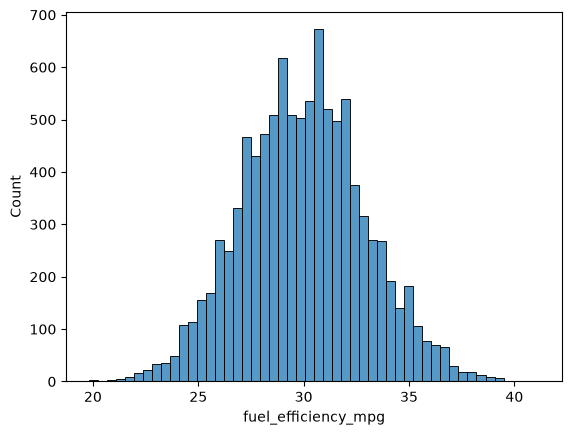

In [5]:
# Explaratory Data Analysis
df_base = df[base]

sns.histplot(df_base.fuel_efficiency_mpg, bins=50)

# df.fuel_efficiency_mpg has not tail

In [6]:
'''
    Question 1:
    There's one column with missing values. What is it?

'''
df.isnull().sum()
# horsepower

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [7]:
'''
    Question:
    What's the median (50% percentile) for variable 'horsepower'?
'''

df.horsepower.describe().round(0)
# 254

count    9123.0
mean      254.0
std        23.0
min       171.0
25%       239.0
50%       254.0
75%       270.0
max       334.0
Name: horsepower, dtype: float64

In [8]:
'''
    Prepare and split the dataset
    Shuffle the filtered dataset and create the split exactly as in the lecture:
'''
# find spliting point
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# shuffle the indexes to use in the data spliting phase
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

# split the data
df_test = df.iloc[idx[n_test:]]
df_val = df.iloc[idx[n_test:n_test + n_val]]
df_train = df.iloc[idx[n_test + n_val:]]

# reset the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [9]:
'''get y_pred and drop its corresponding column'''
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [11]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [12]:
'''
    Prepare a Dataframe for model ingestion
'''
def prepare_X(df):
    df = df.copy()
    # print(df.head())
    features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
    
    # Select numeric/base features
    df_num = df[features]

    return df_num.values


In [13]:
'''
    Question 3
    Filling NaN with 0
'''
df_train['horsepower'] = df_train['horsepower'].fillna(0)
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred).round(3))

df_val['horsepower'] = df_val['horsepower'].fillna(0)
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred).round(3))

train 2.204
validation 2.216


In [14]:
'''
    Question 3
    Filling NaN with mean
'''
mean = df.horsepower.mean()

df_train['horsepower'] = df_train['horsepower'].fillna(mean)
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred).round(3))

df_val['horsepower'] = df_val['horsepower'].fillna(mean)
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation', rmse(y_val, y_pred).round(3))


train 2.204
validation 2.216


In [15]:
# Which option gives better RMSE?
# Both are equally good

In [24]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    
    # weight regularisation
    XTX2 = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX2)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [25]:
'''
    Question 4
'''

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred).round(4)

    print(r, w0, w,  score)
    
# 0.01  has the smallest score

0 nan [nan nan nan nan] nan
0.01 nan [nan nan nan nan] nan
0.1 nan [nan nan nan nan] nan
1 nan [nan nan nan nan] nan
5 nan [nan nan nan nan] nan
10 nan [nan nan nan nan] nan
100 nan [nan nan nan nan] nan


In [18]:
'''
    Question 5
'''
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmses = []

for seed in seeds:
    # For each seed, do the train/validation/test split with 60%/20%/20% distribution.
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_test = df.iloc[idx[n_test:]]
    df_val = df.iloc[idx[n_test:n_test + n_val]]
    df_train = df.iloc[idx[n_test + n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    '''get y_pred and drop its corresponding column'''
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Fill the missing values with 0 and train a model without regularization.
    df_train = df_train.fillna(0)
    df_val = df_val.fillna(0)
    df_test = df_test.fillna(0)


    # For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
    X_train = prepare_X(df_train)
    w_0, w = train_linear_regression(X_train, y_train)
    
    y_pred = w_0 + X_train.dot(w)
    
    X_val = prepare_X(df_val)
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(f"seed={seed}, RMSE_Score={score}")
    rmses.append(score)

std = np.std(rmses)
std.round(3)

# 0.024

seed=0, RMSE_Score=2.22738359180843
seed=1, RMSE_Score=2.2493840794805955
seed=2, RMSE_Score=2.2297574623009324
seed=3, RMSE_Score=2.2408018766523323
seed=4, RMSE_Score=2.2106203582378816
seed=5, RMSE_Score=2.198549047055183
seed=6, RMSE_Score=2.2215904416208008
seed=7, RMSE_Score=2.188653741600753
seed=8, RMSE_Score=2.1950615117044703
seed=9, RMSE_Score=2.169277390905183


np.float64(0.024)

In [19]:
'''Question 6
'''
# Split the dataset like previously, use seed 9.
seed = 9

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(seed)
idx = np.arange(n)
np.random.shuffle(idx)

df_test = df.iloc[idx[n_test:]]
df_val = df.iloc[idx[n_test:n_test + n_val]]
df_train = df.iloc[idx[n_test + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

'''get y_pred and drop its corresponding column'''
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Combine train and validation datasets.

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)


X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])


# Fill the missing values with 0 and train a model with regularization.
df_full_train = df_full_train.fillna(0)
df_test = df_test.fillna(0)


###
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
print(w)
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print(f"test {score}")

[nan nan nan nan]
test nan
